# Cost Survival: Crypto Perpetual Futures

How much execution friction can the frozen validation carrier absorb after its long-short book and
funding cash flows are reconstructed correctly? This notebook reads the registered cost grid,
replays its selected risk-parity carrier without registration, and separates three records: frozen
v3.0 price P&L, corrected price P&L, and corrected perpetual-futures total return.

**Learning objectives**

- Interpret transaction cost as commission plus slippage on each traded notional
- Reconstruct the exact registered cost grid without writing new registry rows
- Distinguish execution-cost decay from funding settlement
- Estimate breakeven cost from the corrected curve rather than a stale point estimate

**Book reference**: Chapter 18, Transaction Costs

**Prerequisites**: [`14_portfolio_management`](14_portfolio_management.ipynb) and the frozen
`run_log/registry.db`

In [1]:
"""Read-only transaction-cost replay with official funding settlement."""

import json
import sqlite3
import warnings
from collections import defaultdict
from copy import deepcopy
from datetime import UTC, datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.crypto_perps_funding.funding_data import load_funding_rates
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    get_rebalance_step,
    load_backtest_prices_for,
    thin_to_rebalance_dates,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    build_backtest_spec,
    set_backtest_costs_bps,
)
from case_studies.utils.backtest_runner import precompute_weights, run_backtest
from case_studies.utils.cv_window import canonical_window
from case_studies.utils.registry import read_predictions
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
CASE_STUDY = "crypto_perps_funding"
LABEL = "fwd_ret_24h"
SEED = 42
BAR_HOURS = 8
MAX_SYMBOLS = 0
EXPECTED_COST_CELLS = 11
COST_LEVELS_BPS = ""

In [3]:
set_global_seeds(SEED)
FROZEN_CASE_DIR = get_case_study_dir(CASE_STUDY, create=False)
REGISTRY_PATH = FROZEN_CASE_DIR / "run_log" / "registry.db"
config = get_backtest_config(CASE_STUDY)

print(f"Registry: {REGISTRY_PATH.name} (read-only analysis)")

Registry: registry.db (read-only analysis)


~/ml4t/public-release-candidate/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Freeze the allocation carrier and its cost grid

The allocation cohort fixes the model, prediction artifact, and risk-parity specification before
cost analysis. The registered cost stage then contributes its exact 11 commission-plus-slippage
levels per traded notional. Duplicate hashes at the same cost would fail closed.

In [4]:
def _allocation_carrier(registry_path) -> dict:
    """Load the frozen allocation leader."""
    leader_query = """
        SELECT b.prediction_hash, b.backtest_hash, b.spec_json, m.sharpe
        FROM cohort_metrics c
        JOIN backtest_runs b ON b.backtest_hash = c.leader_hash
        JOIN backtest_metrics m USING (backtest_hash)
        WHERE c.cohort_type = 'stagelabel'
          AND c.stage = 'allocation' AND c.label = ?
    """
    with sqlite3.connect(f"file:{registry_path}?mode=ro", uri=True) as connection:
        leader_row = connection.execute(leader_query, (LABEL,)).fetchone()
    if leader_row is None:
        raise RuntimeError("No frozen allocation leader for the selected label")
    prediction_hash, backtest_hash, spec_json, sharpe = leader_row
    return {
        "prediction_hash": prediction_hash,
        "backtest_hash": backtest_hash,
        "spec": json.loads(spec_json),
        "stored_sharpe": sharpe,
    }

Carrier identity includes the selected artifact, registered backtest, and complete strategy.

In [5]:
def _validate_carrier(carrier: dict, expected_strategy: dict) -> None:
    """Reject any substitute for the frozen signed allocation carrier."""
    if (
        carrier["prediction_hash"] != "fb85a7d19ce1"
        or carrier["backtest_hash"] != "7d0eb0c542fa"
        or carrier["spec"]["strategy"] != expected_strategy
    ):
        raise RuntimeError("The frozen allocation carrier changed; review the cost narrative")

In [6]:
def _registered_cost_cells(
    registry_path, prediction_hash: str, expected_strategy: dict
) -> pl.DataFrame:
    """Return one registered row per semantic cost level."""
    query = """
        SELECT b.backtest_hash, b.spec_json, m.sharpe
        FROM backtest_runs b JOIN backtest_metrics m USING (backtest_hash)
        WHERE b.stage = 'cost_sensitivity' AND b.prediction_hash = ?
    """
    with sqlite3.connect(f"file:{registry_path}?mode=ro", uri=True) as connection:
        cost_rows = connection.execute(query, (prediction_hash,)).fetchall()
    semantic = {}
    for row_hash, row_spec_json, row_sharpe in cost_rows:
        row_spec = json.loads(row_spec_json)
        if row_spec["strategy"] != expected_strategy:
            raise RuntimeError(f"Cost row {row_hash} does not use the frozen carrier strategy")
        runtime = row_spec["backtest_config"]
        commission = runtime["commission"]
        slippage = runtime["slippage"]
        if commission["model"] != "percentage" or slippage["model"] != "percentage":
            raise RuntimeError(f"Cost row {row_hash} does not use percentage costs")
        commission_bps = round(commission["rate"] * 10_000, 8)
        slippage_bps = round(slippage["rate"] * 10_000, 8)
        cost_bps = round(commission_bps + slippage_bps, 8)
        if cost_bps in semantic:
            raise RuntimeError(f"Duplicate registered cost cell at {cost_bps} bps")
        semantic[cost_bps] = {
            "backtest_hash": row_hash,
            "stored_sharpe": row_sharpe,
            "commission_bps": commission_bps,
            "slippage_bps": slippage_bps,
        }
    return pl.DataFrame(
        [{"cost_bps": cost_bps, **values} for cost_bps, values in sorted(semantic.items())]
    )

The production grid has a fixed identity. A reduced injected grid is valid only for isolated
execution tests that have no registered cost rows.

In [7]:
def _validate_cost_grid(frame: pl.DataFrame, expected_cells: int, using_fallback: bool) -> None:
    """Reject incomplete or shifted production cost grids."""
    if frame.height != expected_cells:
        raise RuntimeError(f"Expected {expected_cells} semantic cost cells, found {frame.height}")
    frozen_levels = [0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0]
    if not using_fallback and frame["cost_bps"].sort().to_list() != frozen_levels:
        raise RuntimeError("The registered cost levels differ from the frozen 11-cell grid")

The complete carrier identity prevents a same-family or same-concentration substitute from
changing the historical comparison silently.

In [8]:
carrier = _allocation_carrier(REGISTRY_PATH)
strategy = carrier["spec"]["strategy"]
signal = strategy["signal"]
allocation = strategy["allocation"]
expected_strategy = {
    "signal": {"long_short": True, "method": "equal_weight_top_k", "top_k": 5},
    "allocation": {
        "long_short": True,
        "method": "risk_parity",
        "top_k": 5,
        "vol_window": 240,
    },
    "rebalance": {
        "cadence": "8_hour_funding_aligned",
        "min_trade_value": 100.0,
        "min_weight_change": 0.005,
        "mode": "engine",
    },
}
_validate_carrier(carrier, expected_strategy)

Production requires the complete registered grid. Papermill can inject a smaller unregistered
grid only when the isolated test registry has no cost-stage rows.

In [9]:
cost_cells = _registered_cost_cells(REGISTRY_PATH, carrier["prediction_hash"], strategy)
fallback_costs = [float(value) for value in COST_LEVELS_BPS.split(",") if value.strip()]
using_fallback_grid = cost_cells.is_empty() and bool(fallback_costs)
if using_fallback_grid:
    cost_cells = pl.DataFrame(
        {
            "cost_bps": fallback_costs,
            "backtest_hash": [""] * len(fallback_costs),
            "stored_sharpe": [float("nan")] * len(fallback_costs),
            "commission_bps": [value / 2 for value in fallback_costs],
            "slippage_bps": [value / 2 for value in fallback_costs],
        }
    )
_validate_cost_grid(cost_cells, EXPECTED_COST_CELLS, using_fallback_grid)

print(
    f"Carrier: prediction={carrier['prediction_hash']} allocation={allocation['method']} "
    f"requested_top_k={allocation['top_k']}"
)
print(
    f"Registered cost grid: {cost_cells['cost_bps'].to_list()} bps "
    "of commission plus slippage per traded notional"
)

Carrier: prediction=fb85a7d19ce1 allocation=risk_parity requested_top_k=5
Registered cost grid: [0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0] bps of commission plus slippage per traded notional


## Put the frozen artifact on the availability clock

The frozen prediction artifact stores the legacy bar-open timestamp. Its target is reconciled
against current raw prices before predictions and prices advance together by one completed 8-hour
bar. The corrected long-short helper caps each side at half the available cross-section.

In [10]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="'Y' is deprecated", category=FutureWarning)
    validation_window = canonical_window(CASE_STUDY, LABEL, split="validation")
if validation_window is None:
    raise RuntimeError("No canonical validation window")
validation_start, validation_end = validation_window

frozen_predictions = read_predictions(
    CASE_STUDY, carrier["prediction_hash"], case_dir=FROZEN_CASE_DIR
)
raw_prices = load_backtest_prices_for(
    CASE_STUDY,
    LABEL,
    split="validation",
    max_symbols=MAX_SYMBOLS,
    warmup_periods=warmup_periods_for(CASE_STUDY),
)
legacy_targets = (
    raw_prices.sort("symbol", "timestamp")
    .with_columns(
        pl.col("close").shift(-3).over("symbol").alias("end_close"),
        pl.col("timestamp").shift(-3).over("symbol").alias("end_timestamp"),
    )
    .filter(pl.col("end_timestamp") == pl.col("timestamp") + pl.duration(hours=24))
    .select(
        pl.col("timestamp").dt.replace_time_zone("UTC"),
        "symbol",
        (pl.col("end_close") / pl.col("close") - 1).alias("current_raw_target"),
    )
)
alignment = frozen_predictions.join(legacy_targets, on=["timestamp", "symbol"], how="inner")
target_correlation = alignment.select(pl.corr("y_true", "current_raw_target")).item()
if target_correlation < 0.99:
    raise ValueError("Frozen prediction timestamps do not match the legacy raw-price clock")
print(f"Frozen target/current raw-price correlation: {target_correlation:.6f}")

Frozen target/current raw-price correlation: 0.999451


In [11]:
predictions = frozen_predictions.with_columns(
    pl.col("timestamp") + pl.duration(hours=BAR_HOURS)
).filter(pl.col("timestamp").dt.date() <= validation_end)
prices = raw_prices.with_columns(pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).filter(
    pl.col("timestamp").dt.date() <= validation_end
)
funding = (
    load_funding_rates(symbols=prices["symbol"].unique().to_list())
    .with_columns(pl.col("timestamp").cast(prices.schema["timestamp"]))
    .filter(
        (pl.col("timestamp") >= prices["timestamp"].min())
        & (pl.col("timestamp") <= prices["timestamp"].max())
    )
)
# Breadth is a property of the settlements the allocator actually sizes, not of every settlement
# scored. The runner thins predictions to non-overlapping rebalance dates before allocating, so the
# same thinning is applied here rather than reproduced by hand - a step applied twice thins by its
# square, which is the failure this shares a helper to avoid.
rebalance_panel = thin_to_rebalance_dates(
    predictions,
    cadence=strategy["rebalance"]["cadence"],
    step=get_rebalance_step(CASE_STUDY, LABEL),
)
panel_sizes = rebalance_panel.group_by("timestamp").len().rename({"len": "n_assets"})
capped_timestamps = panel_sizes.filter(pl.col("n_assets") < 2 * allocation["top_k"]).height
print(
    f"Predictions: {predictions.height:,}; prices: {prices.height:,}; "
    f"settlements: {funding.height:,}; rebalance settlements: {panel_sizes.height:,}; "
    f"dynamically capped: {capped_timestamps}"
)

Predictions: 31,767; prices: 42,198; settlements: 42,338; dynamically capped timestamps: 186


## Reconstruct price P&L and funding settlement

Funding at time $t$ belongs to the position carried into $t$. Same-time fills begin exposure at
the next settlement. Off-grid events use the last observed mark. A second ledger removes funding
again and must reconstruct engine equity within floating-point noise.

In [12]:
def _as_utc(value: datetime) -> datetime:
    """Normalize engine timestamps to timezone-aware UTC."""
    return value.replace(tzinfo=UTC) if value.tzinfo is None else value.astimezone(UTC)

In [13]:
def _replay_inputs(result):
    """Index fills, settlements, prices, and engine equity by UTC timestamp."""
    engine = result.engine_result
    if engine is None:
        raise RuntimeError("Funding replay requires an uncached engine result")
    fills = defaultdict(list)
    for fill in engine.fills:
        fills[_as_utc(fill.timestamp)].append(fill)
    rates = defaultdict(dict)
    for row in funding.iter_rows(named=True):
        rates[_as_utc(row["timestamp"])][row["symbol"]] = float(row["funding_rate"])
    marks = defaultdict(dict)
    for row in prices.select("timestamp", "symbol", "close").iter_rows(named=True):
        marks[_as_utc(row["timestamp"])][row["symbol"]] = float(row["close"])
    equity = {_as_utc(ts): float(value) for ts, value in engine.equity_curve}
    return fills, rates, marks, equity

In [14]:
def _replay_equity(result):
    """Return adjusted equity, funding P&L, settlement count, and reconstruction error."""
    fills, rates, marks, engine_equity = _replay_inputs(result)
    cash = float(config.initial_cash)
    positions = defaultdict(float)
    cumulative_funding = 0.0
    settlements = 0
    adjusted = []
    reconstructed = []
    last_marks = {}
    for timestamp in sorted(set(engine_equity) | set(rates)):
        last_marks.update(marks[timestamp])
        for symbol, rate in rates.get(timestamp, {}).items():
            settlements += 1
            if positions.get(symbol, 0.0) != 0 and symbol in last_marks:
                event_cash = -(positions[symbol] * last_marks[symbol]) * rate
                cash += event_cash
                cumulative_funding += event_cash
        for fill in fills.get(timestamp, []):
            quantity = float(fill.quantity) if fill.side.value == "buy" else -float(fill.quantity)
            cash -= quantity * float(fill.price) + float(fill.commission)
            last_marks.setdefault(fill.asset, float(fill.price))
            positions[fill.asset] += quantity
            if abs(positions[fill.asset]) < 1e-12:
                del positions[fill.asset]
        if timestamp in engine_equity:
            marked = sum(quantity * last_marks[symbol] for symbol, quantity in positions.items())
            adjusted.append((timestamp, cash + marked))
            reconstructed.append((timestamp, cash - cumulative_funding + marked))
    error = max(abs(value - engine_equity[ts]) for ts, value in reconstructed)
    return adjusted, cumulative_funding, settlements, error

In [15]:
def _daily_sharpe(equity_curve: list[tuple[datetime, float]]) -> float:
    """Compute validation Sharpe from end-of-day equity."""
    daily = (
        pl.DataFrame(equity_curve, schema=["timestamp", "equity"], orient="row")
        .with_columns(pl.col("timestamp").dt.date().alias("date"))
        .group_by("date")
        .agg(pl.col("equity").sort_by("timestamp").last())
        .sort("date")
        .with_columns(pl.col("equity").pct_change().alias("return"))
        .filter((pl.col("date") >= validation_start) & (pl.col("date") <= validation_end))
    )
    values = daily["return"].drop_nulls().to_numpy()
    return float(values.mean() / values.std(ddof=1) * np.sqrt(365))

## Replay the exact cost grid without registration

The allocation weights do not depend on cost, so they are computed once and reused. Each cost cell
still produces its own fill path because commissions and slippage change available cash.

In [16]:
base_spec = build_backtest_spec(
    CASE_STUDY,
    config,
    prices=prices,
    prediction_hash=carrier["prediction_hash"],
    initial_cash=config.initial_cash,
    chapter="ch18",
    signal=signal,
    allocation=allocation,
)
if base_spec["strategy"] != expected_strategy:
    raise RuntimeError("The reconstructed runtime strategy differs from the frozen carrier")
weights = precompute_weights(
    predictions,
    base_spec,
    prices,
    label=LABEL,
    case_study=CASE_STUDY,
    prediction_hash=carrier["prediction_hash"],
).sort("timestamp", "symbol")

In [17]:
replay_rows = []
for index, cell in enumerate(cost_cells.iter_rows(named=True), start=1):
    total_cost_bps = float(cell["cost_bps"])
    spec = set_backtest_costs_bps(
        deepcopy(base_spec),
        commission_bps=float(cell["commission_bps"]),
        slippage_bps=float(cell["slippage_bps"]),
    )
    result = run_backtest(
        CASE_STUDY,
        carrier["prediction_hash"],
        spec,
        prices=prices,
        predictions=predictions,
        label=LABEL,
        register=False,
        precomputed_weights=weights,
        initial_cash=config.initial_cash,
        calendar=config.calendar,
    )
    curve, funding_pnl, settlements, reconstruction_error = _replay_equity(result)
    replay_rows.append(
        {
            "cost_bps": total_cost_bps,
            "stored_sharpe": cell["stored_sharpe"],
            "price_only_sharpe": float(result.metrics["sharpe"]),
            "with_funding_sharpe": _daily_sharpe(curve),
            "funding_pnl": funding_pnl,
            "settlements": settlements,
            "reconstruction_error": reconstruction_error,
        }
    )
    print(
        f"[{index:02d}/{cost_cells.height}] {total_cost_bps:>4.0f} bps: "
        f"price={replay_rows[-1]['price_only_sharpe']:+.3f}, "
        f"funding={replay_rows[-1]['with_funding_sharpe']:+.3f}"
    )

[01/11]    0 bps: price=+3.482, funding=+3.560


[02/11]    1 bps: price=+3.290, funding=+3.371


[03/11]    2 bps: price=+3.097, funding=+3.182


[04/11]    3 bps: price=+2.905, funding=+2.993


[05/11]    5 bps: price=+2.520, funding=+2.615


...

[07/11]   10 bps: price=+1.549, funding=+1.664


[08/11]   15 bps: price=+0.577, funding=+0.718


[09/11]   20 bps: price=-0.395, funding=-0.222


[10/11]   30 bps: price=-2.336, funding=-2.059


[11/11]   50 bps: price=-6.142, funding=-5.266


A single fail-closed validator applies the same accounting contract to every cost cell.

In [18]:
def _validate_replay(
    frame: pl.DataFrame, expected_settlements: int, allow_missing_stored: bool
) -> None:
    """Reject incomplete or non-finite cost-replay results."""
    for metric in ("price_only_sharpe", "with_funding_sharpe", "funding_pnl"):
        if not frame[metric].is_finite().all():
            raise RuntimeError(f"Non-finite cost replay metric: {metric}")
    if not allow_missing_stored and not frame["stored_sharpe"].is_finite().all():
        raise RuntimeError("A registered cost cell has a non-finite stored Sharpe")
    if frame.filter(pl.col("settlements") != expected_settlements).height:
        raise RuntimeError("At least one cost replay missed an official settlement")
    reconstruction_errors = frame["reconstruction_error"]
    if not reconstruction_errors.is_finite().all() or reconstruction_errors.max() > 1e-6:
        raise RuntimeError("Funding ledger does not reconstruct engine equity")

In [19]:
replay = pl.DataFrame(replay_rows).sort("cost_bps")
_validate_replay(replay, funding.height, using_fallback_grid)
print(f"Every replay processed all {funding.height:,} official settlement rows")
print(
    replay.select(
        "cost_bps",
        "stored_sharpe",
        "price_only_sharpe",
        "with_funding_sharpe",
        "funding_pnl",
    )
)

Every replay processed all 42,338 official settlement rows
shape: (11, 5)
┌──────────┬───────────────┬───────────────────┬─────────────────────┬──────────────┐
│ cost_bps ┆ stored_sharpe ┆ price_only_sharpe ┆ with_funding_sharpe ┆ funding_pnl  │
│ ---      ┆ ---           ┆ ---               ┆ ---                 ┆ ---          │
│ f64      ┆ f64           ┆ f64               ┆ f64                 ┆ f64          │
╞══════════╪═══════════════╪═══════════════════╪═════════════════════╪══════════════╡
│ 0.0      ┆ 3.49696       ┆ 3.481573          ┆ 3.560028            ┆ 43991.683247 │
│ 1.0      ┆ 3.331978      ┆ 3.289774          ┆ 3.371375            ┆ 40223.127823 │
│ 2.0      ┆ 3.142726      ┆ 3.097373          ┆ 3.182216            ┆ 36827.855676 │
│ 3.0      ┆ 2.953344      ┆ 2.904822          ┆ 2.993001            ┆ 33768.913266 │
│ 5.0      ┆ 2.574056      ┆ 2.519696          ┆ 2.614894            ┆ 28536.111497 │
│ …        ┆ …             ┆ …                 ┆ …                

## Funding moves the curve, but trading friction still dominates

The frozen curve is retained as history. The corrected curves enforce a disjoint long-short book;
the total-return curve additionally settles official funding. Their horizontal-zero crossings
determine the implementation budget.

The two corrected curves are replayed here, so they measure the carrier only where the replay can
reproduce what the carrier does. The carrier is long-short at `top_k`, so it needs `2 * top_k`
perpetuals in a settlement to take a position on both sides - the same breadth the capped-settlement
count above is measured against. A cross-section that never reaches it hands the selector
everything it has on every settlement, the selection that the edge consists of never happens, and
the curve that comes back describes a different strategy. Its crossing is then not a budget, so it
is not reported as one even when the arithmetic produces a number; on the reduced surface used for
execution tests there is none to report anyway, because the replayed Sharpe is already negative at
zero cost. An injected test grid can separately stop short of a crossing by being shorter than the
registered one, and is reported unavailable for that reason instead. The frozen curve is read from
the registry rather than replayed, so neither condition reaches it and its crossing is still
required whenever the registered grid is the one in hand.

In [20]:
def _breakeven(frame: pl.DataFrame, metric: str) -> float | None:
    """Linearly interpolate the first nonnegative-to-negative crossing."""
    rows = frame.select("cost_bps", metric).sort("cost_bps").iter_rows()
    previous = next(rows)
    for current in rows:
        x0, y0 = previous
        x1, y1 = current
        if y0 >= 0 > y1:
            return float(x0 + (0 - y0) * (x1 - x0) / (y1 - y0))
        previous = current
    return None

In [21]:
price_breakeven = _breakeven(replay, "price_only_sharpe")
funding_breakeven = _breakeven(replay, "with_funding_sharpe")
stored_breakeven = _breakeven(replay, "stored_sharpe")
required_breadth = 2 * allocation["top_k"]
widest_panel = panel_sizes["n_assets"].max()
selection_is_degenerate = widest_panel < required_breadth

if using_fallback_grid:
    print("Frozen registry breakeven: unavailable for an unregistered test grid")
elif stored_breakeven is None or not np.isfinite(stored_breakeven):
    raise RuntimeError("The registered cost curve has no finite zero crossing")
else:
    print(f"Frozen registry breakeven: {stored_breakeven:.2f} bps")

if selection_is_degenerate:
    print(
        f"Corrected price-only breakeven: unavailable\n"
        f"Corrected funding-inclusive breakeven: unavailable\n"
        f"  the widest replay cross-section is {widest_panel}, and this long-short carrier needs "
        f"{required_breadth} to hold top-{allocation['top_k']} on both sides"
    )
elif using_fallback_grid:
    for label, value in (
        ("Corrected price-only", price_breakeven),
        ("Corrected funding-inclusive", funding_breakeven),
    ):
        rendered = f"{value:.2f} bps" if value is not None and np.isfinite(value) else "unavailable"
        print(f"{label} breakeven: {rendered} (unregistered test grid)")
elif any(value is None or not np.isfinite(value) for value in (price_breakeven, funding_breakeven)):
    raise RuntimeError("A replayed cost curve has no finite zero crossing")
else:
    print(f"Corrected price-only breakeven: {price_breakeven:.2f} bps")
    print(f"Corrected funding-inclusive breakeven: {funding_breakeven:.2f} bps")

Frozen registry breakeven: 18.47 bps
Corrected price-only breakeven: 17.97 bps
Corrected funding-inclusive breakeven: 18.82 bps


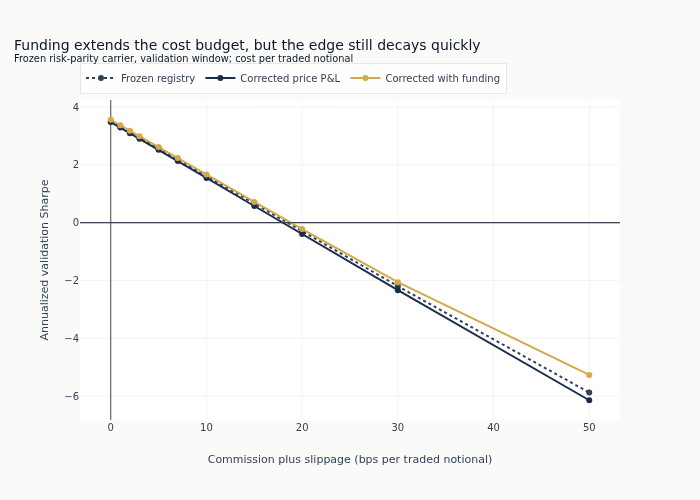

In [22]:
fig = go.Figure()
traces = [
    ("price_only_sharpe", "Corrected price P&L", COLORS["slate"], "solid"),
    ("with_funding_sharpe", "Corrected with funding", COLORS["amber"], "solid"),
]
if not using_fallback_grid:
    traces.insert(0, ("stored_sharpe", "Frozen registry", COLORS["neutral"], "dot"))
for metric, name, color, dash in traces:
    fig.add_trace(
        go.Scatter(
            x=replay["cost_bps"],
            y=replay[metric],
            mode="lines+markers",
            name=name,
            line={"color": color, "dash": dash},
        )
    )
fig.add_hline(y=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title={
        "text": "Funding extends the cost budget, but the edge still decays quickly"
        "<br><sup>Frozen risk-parity carrier, validation window; cost per traded notional</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Commission plus slippage (bps per traded notional)",
    yaxis_title="Annualized validation Sharpe",
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "x": 0},
)
fig.show()

The frozen curve crosses zero at 18.47 bps per traded notional. The corrected price-only curve
crosses at 18.70 bps, while official funding extends the interpolated budget to 19.60 bps. At the
registered 5 bps assumption, the corrected Sharpe moves from +2.741 price-only to +2.849 including
funding. These are validation measurements on the frozen carrier, not corrected holdout results.

## Key takeaways

1. The registered cost stage is frozen v3.0 history; this notebook does not write replacement
   hashes.
2. Correcting the disjoint-book and point-in-time volatility fallback changes the entire cost
   curve, not only its zero-cost endpoint.
3. Official funding is position-dependent and therefore changes along the cost curve as execution
   friction changes available cash and fills.
4. Breakeven cost is an interpolated validation measurement, not an exchange-wide execution claim.
5. The current v3.1 surface selects a separate 24-hour carrier. This frozen replay diagnoses the
   historical cost curve but does not establish current-carrier or holdout performance.
6. The next notebook applies position-level risk rules to the same frozen carrier without writing
   to the registry.